# Ratings Descriptive Analysis

This notebook merges the three ratings files into one dataframe and keeps reusable helper functions in one place, so later descriptive analysis cells can stay short.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)

preferred_fonts = [
    "PingFang SC",
    "Hiragino Sans GB",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_FILES = [
    Path("huxiaoli_ipad_ratings.csv"),
    Path("miquan_ipad_ratings.csv"),
    Path("miquan_ratings.csv"),
]

RATING_COLUMNS = [
    "overall_rating", "剧情", "推理", "悬疑", "欢乐", "情感", "机制", "还原",
    "沉浸", "演绎", "玩法", "故事", "难度", "互动", "立意", "阵营",
    "本格", "变格", "恐怖", "硬核",
]
COUNT_COLUMNS = ["want_count", "played_count", "review_count"]

## Helper Functions

In [15]:
def load_rating_file(path: Path) -> pd.DataFrame:
    """Load one ratings CSV and add source metadata."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["source_file"] = path.name
    df["source_app"] = "huxiaoli" if "huxiaoli" in path.stem else "miquan"
    df["source_platform"] = "ipad" if "ipad" in path.stem else "mobile"
    return df


def merge_rating_files(paths: list[Path]) -> pd.DataFrame:
    """Merge ratings files with consistent column order and numeric types."""
    merged = pd.concat([load_rating_file(path) for path in paths], ignore_index=True, sort=False)
    numeric_columns = [col for col in RATING_COLUMNS + COUNT_COLUMNS if col in merged.columns]
    merged[numeric_columns] = merged[numeric_columns].apply(pd.to_numeric, errors="coerce")
    return merged


def summarize_missing(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.isna()
        .sum()
        .to_frame("missing_count")
        .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
        .sort_values("missing_count", ascending=False)
    )


def summarize_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    available_columns = [col for col in columns if col in df.columns]
    return df[available_columns].describe().T

## Load And Merge

In [16]:
ratings = merge_rating_files(DATA_FILES)

print(f"Merged rows: {len(ratings):,}")
print(f"Columns: {ratings.shape[1]:,}")
ratings.head()

Merged rows: 3,379
Columns: 31


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
0,龙傲天,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1,蜕变俱乐部2,蜕变俱乐部2：海的女儿,7.200,7.100,0.000,0.000,0.000,6.500,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7607.000,14689.000,198,阿斯巴甜,4男3女 4.0小时 高阶 2020.08发行,欧美 机制 沉浸 童话,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
2,今夕何夕,今夕何夕,6.700,7.000,6.400,0.000,0.000,6.900,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.800,19494.000,250,KEYS工作室,5男2女 4.5小时 进阶 2020.08发行,古风 推理 沉浸 家国,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
3,蜕变俱乐部,蜕变俱乐部,7.300,7.200,0.000,7.100,0.000,0.000,7.100,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.600,17865.000,239,阿斯巴甜,4男3女 5.0小时 高阶 2020.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
4,土狗,土狗,8.000,7.700,0.000,7.600,0.000,0.000,0.000,8.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,5049.000,37782.000,5692,解语花剧本工作室,4男2女 7.0小时 进阶 2025.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [17]:
ratings["source_file"].value_counts().rename_axis("source_file").to_frame("rows")

,rows
source_file,
miquan_ipad_ratings.csv,1657
huxiaoli_ipad_ratings.csv,1316
miquan_ratings.csv,406


## Duplicate Check

In [18]:
duplicate_keys = ["query"]
duplicate_mask = ratings.duplicated(subset=duplicate_keys, keep=False)

print(f"Rows sharing query: {duplicate_mask.sum():,}")
ratings.loc[duplicate_mask].sort_values(duplicate_keys).head(10)

Rows sharing query: 807


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
484,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1513,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
3328,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
507,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1395,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
3099,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
3004,Hi老妖婆,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
1340,Hi老妖婆,HI！老妖婆,7.400,7.200,0.000,0.000,7.400,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,16909.000,18609.000,808,气球文娱,3男3女 4.0小时 新手 2023.02发行,【剧本杀测评】 📖剧本名称：HI！老妖婆 👫🏼游戏人数：3男3女（可反串） ⏰游戏时长：4h...,miquan_ipad_ratings.csv,miquan,ipad
2606,IDO,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
185,IDO,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [19]:
rating_columns = [col for col in RATING_COLUMNS if col in ratings.columns]
has_nonzero_rating = (
    ratings[rating_columns].fillna(0).ne(0).any(axis=1)
    if rating_columns
    else pd.Series(False, index=ratings.index)
)

ratings_with_rating_flag = ratings.assign(_has_nonzero_rating=has_nonzero_rating)
keep_indices = []
for _, group in ratings_with_rating_flag.groupby("query", sort=False):
    nonzero_indices = group.index[group["_has_nonzero_rating"]]
    if len(nonzero_indices) > 0:
        keep_indices.extend(nonzero_indices.tolist())
    else:
        keep_indices.append(group.index[0])

ratings_deduped = ratings_with_rating_flag.loc[keep_indices].drop(columns="_has_nonzero_rating")

print(f"Rows after dedupe preference: {len(ratings_deduped):,}")
ratings_deduped.head()

Rows after dedupe preference: 2,957


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
0,龙傲天,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1,蜕变俱乐部2,蜕变俱乐部2：海的女儿,7.200,7.100,0.000,0.000,0.000,6.500,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7607.000,14689.000,198,阿斯巴甜,4男3女 4.0小时 高阶 2020.08发行,欧美 机制 沉浸 童话,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
2,今夕何夕,今夕何夕,6.700,7.000,6.400,0.000,0.000,6.900,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.800,19494.000,250,KEYS工作室,5男2女 4.5小时 进阶 2020.08发行,古风 推理 沉浸 家国,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
3,蜕变俱乐部,蜕变俱乐部,7.300,7.200,0.000,7.100,0.000,0.000,7.100,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.600,17865.000,239,阿斯巴甜,4男3女 5.0小时 高阶 2020.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
4,土狗,土狗,8.000,7.700,0.000,7.600,0.000,0.000,0.000,8.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,5049.000,37782.000,5692,解语花剧本工作室,4男2女 7.0小时 进阶 2025.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [20]:
query_counts = ratings_deduped["query"].value_counts()
duplicate_query_counts = query_counts[query_counts > 1]

affected_queries = duplicate_query_counts.index.tolist()
print(f"Duplicate query names remaining in ratings_deduped: {len(duplicate_query_counts):,}")
if duplicate_query_counts.empty:
    print("No duplicate queries remain.")
else:
    print("Duplicate query row(s):")
    for query in affected_queries:
        rows = ratings_deduped.loc[ratings_deduped["query"] == query]
        print(f"\nQuery: {query}")
        print(rows.to_string(index=False))

Duplicate query names remaining in ratings_deduped: 1
Duplicate query row(s):

Query: 绣春刀
query script_title  overall_rating    剧情    推理    悬疑    欢乐    情感    机制    还原    沉浸    演绎    玩法  故事  难度  互动    立意    阵营  本格  变格  恐怖  硬核  want_count  played_count  review_count publishers      metadata        tags             source_file source_app source_platform
  绣春刀          绣春刀           7.100 7.100 0.000 0.000 0.000 7.100 6.900 0.000 0.000 0.000 0.000   0   0   0 0.000 0.000   0   0   0   0    7609.000      3477.000            62  一闪工作室; 草庐 3男4女 4.5小时 新手 古风 机制 沉浸 武侠 miquan_ipad_ratings.csv     miquan            ipad
  绣春刀          绣春刀           7.100 7.100 0.000 0.000 0.000 7.100 6.900 0.000 0.000 0.000 0.000   0   0   0 0.000 0.000   0   0   0   0    7609.000      3473.000            62  一闪工作室; 草庐 3男4女 4.5小时 新手 古风 机制 沉浸 武侠      miquan_ratings.csv     miquan          mobile


In [21]:
ratings_deduped = ratings_deduped.loc[~(
    (ratings_deduped["query"] == "绣春刀")
    & (ratings_deduped["source_file"] == "miquan_ratings.csv")
)].copy()

print(f"Rows after dropping the second 绣春刀 row: {len(ratings_deduped):,}")
ratings_deduped[ratings_deduped["query"] == "绣春刀"]

Rows after dropping the second 绣春刀 row: 2,956


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
1316,绣春刀,绣春刀,7.100,7.100,0.000,0.000,0.000,7.100,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7609.000,3477.000,62,一闪工作室; 草庐,3男4女 4.5小时 新手,古风 机制 沉浸 武侠,miquan_ipad_ratings.csv,miquan,ipad


## Basic Summary

In [33]:
basic_stats_columns = RATING_COLUMNS + COUNT_COLUMNS
filtered_basic_stats = summarize_numeric(ratings_no_zero_one, basic_stats_columns)

print(f"Scripts with overall_rating > 1: {len(ratings_no_zero_one):,}")
print(f"Columns included in basic stats: {len([col for col in basic_stats_columns if col in ratings_no_zero_one.columns]):,}")
filtered_basic_stats

Scripts with overall_rating > 1: 2,109
Columns included in basic stats: 23


,count,mean,std,min,25%,50%,75%,max
overall_rating,2109.000,6.909,1.373,2.000,6.200,7.000,7.800,10.000
剧情,2109.000,5.488,2.907,0.000,5.900,6.800,7.200,8.900
推理,2109.000,2.350,3.273,0.000,0.000,0.000,6.400,8.900
悬疑,2109.000,0.902,2.337,0.000,0.000,0.000,0.000,8.600
欢乐,2109.000,1.033,2.481,0.000,0.000,0.000,0.000,8.600
情感,2109.000,1.869,3.147,0.000,0.000,0.000,6.200,8.900
机制,2109.000,1.036,2.442,0.000,0.000,0.000,0.000,8.900
还原,2109.000,0.564,1.938,0.000,0.000,0.000,0.000,8.600
沉浸,2109.000,0.971,2.466,0.000,0.000,0.000,0.000,8.900
演绎,2109.000,0.473,1.819,0.000,0.000,0.000,0.000,8.700


## Rating Distributions

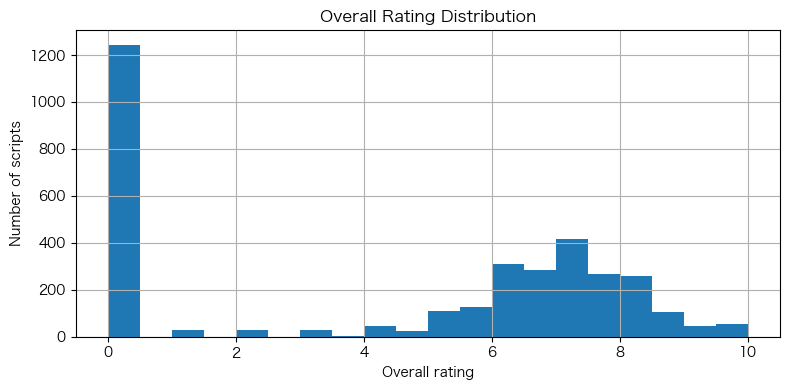

In [22]:
ratings["overall_rating"].hist(bins=20, figsize=(8, 4))
plt.title("Overall Rating Distribution")
plt.xlabel("Overall rating")
plt.ylabel("Number of scripts")
plt.tight_layout()

Overall rating 0/1 summary:
   count    pct
0   1243 36.786
1     27  0.799
Rows with overall_rating > 1: 2,109


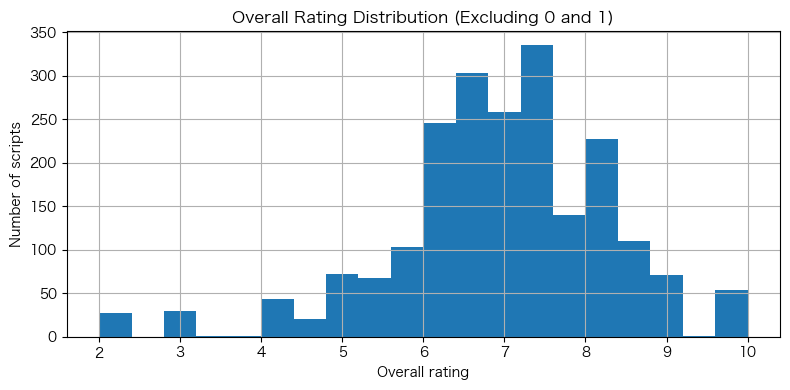

In [26]:
overall_rating = ratings["overall_rating"].dropna()
total_rows = len(overall_rating)
zero_count = (overall_rating == 0).sum()
one_count = (overall_rating == 1).sum()

rating_zero_one_summary = pd.DataFrame(
    {
        "count": [zero_count, one_count],
        "pct": [zero_count / total_rows * 100, one_count / total_rows * 100],
    },
    index=[0, 1],
)

print("Overall rating 0/1 summary:")
print(rating_zero_one_summary.to_string())

ratings_no_zero_one = ratings.loc[ratings["overall_rating"].gt(1)].copy()
print(f"Rows with overall_rating > 1: {len(ratings_no_zero_one):,}")

ratings_no_zero_one["overall_rating"].hist(bins=20, figsize=(8, 4))
plt.title("Overall Rating Distribution (Excluding 0 and 1)")
plt.xlabel("Overall rating")
plt.ylabel("Number of scripts")
plt.tight_layout()

In [27]:
rating_one_scripts = ratings.loc[ratings["overall_rating"].eq(1), [
    "query",
    "script_title",
    "overall_rating",
    "source_file",
    "source_app",
    "source_platform",
    "played_count",
    "review_count",
    "tags",
]].sort_values(["query", "script_title", "source_file"])

print(f"Scripts with overall_rating == 1: {len(rating_one_scripts):,}")
rating_one_scripts

Scripts with overall_rating == 1: 27


,query,script_title,overall_rating,source_file,source_app,source_platform,played_count,review_count,tags
3011,不止清晨不止雾,不止清晨不止雾,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,中式 情感 沉浸 都市
1644,仙尽,仙尽,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,古风 推理 沉浸 武侠
1710,冰川之下,冰川之下,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
346,吃来的爱,吃来的爱,1.000,huxiaoli_ipad_ratings.csv,huxiaoli,ipad,0.000,0,中式 推理 欢乐 科幻
3008,大丸子戏剧团,大丸子戏剧团,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,中式 其他 欢乐 新手
2367,天罚,天罚,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
2329,寓盖弥彰,寓盖弥彰,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
3149,心之所向,心之所向,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,架空 情感 沉浸 校园
3033,忘了忘不了,忘了忘不了,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,NaN
2591,恶童,恶童,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN


Confirmed that rows with overall_rating == 1 contain no meaningful data and should be ignored.

Note: some rating subcategories only have 0 values after filtering, so they are excluded from the plots below.
Zero-only subcategories: 故事, 难度, 互动, 本格, 变格, 恐怖, 硬核


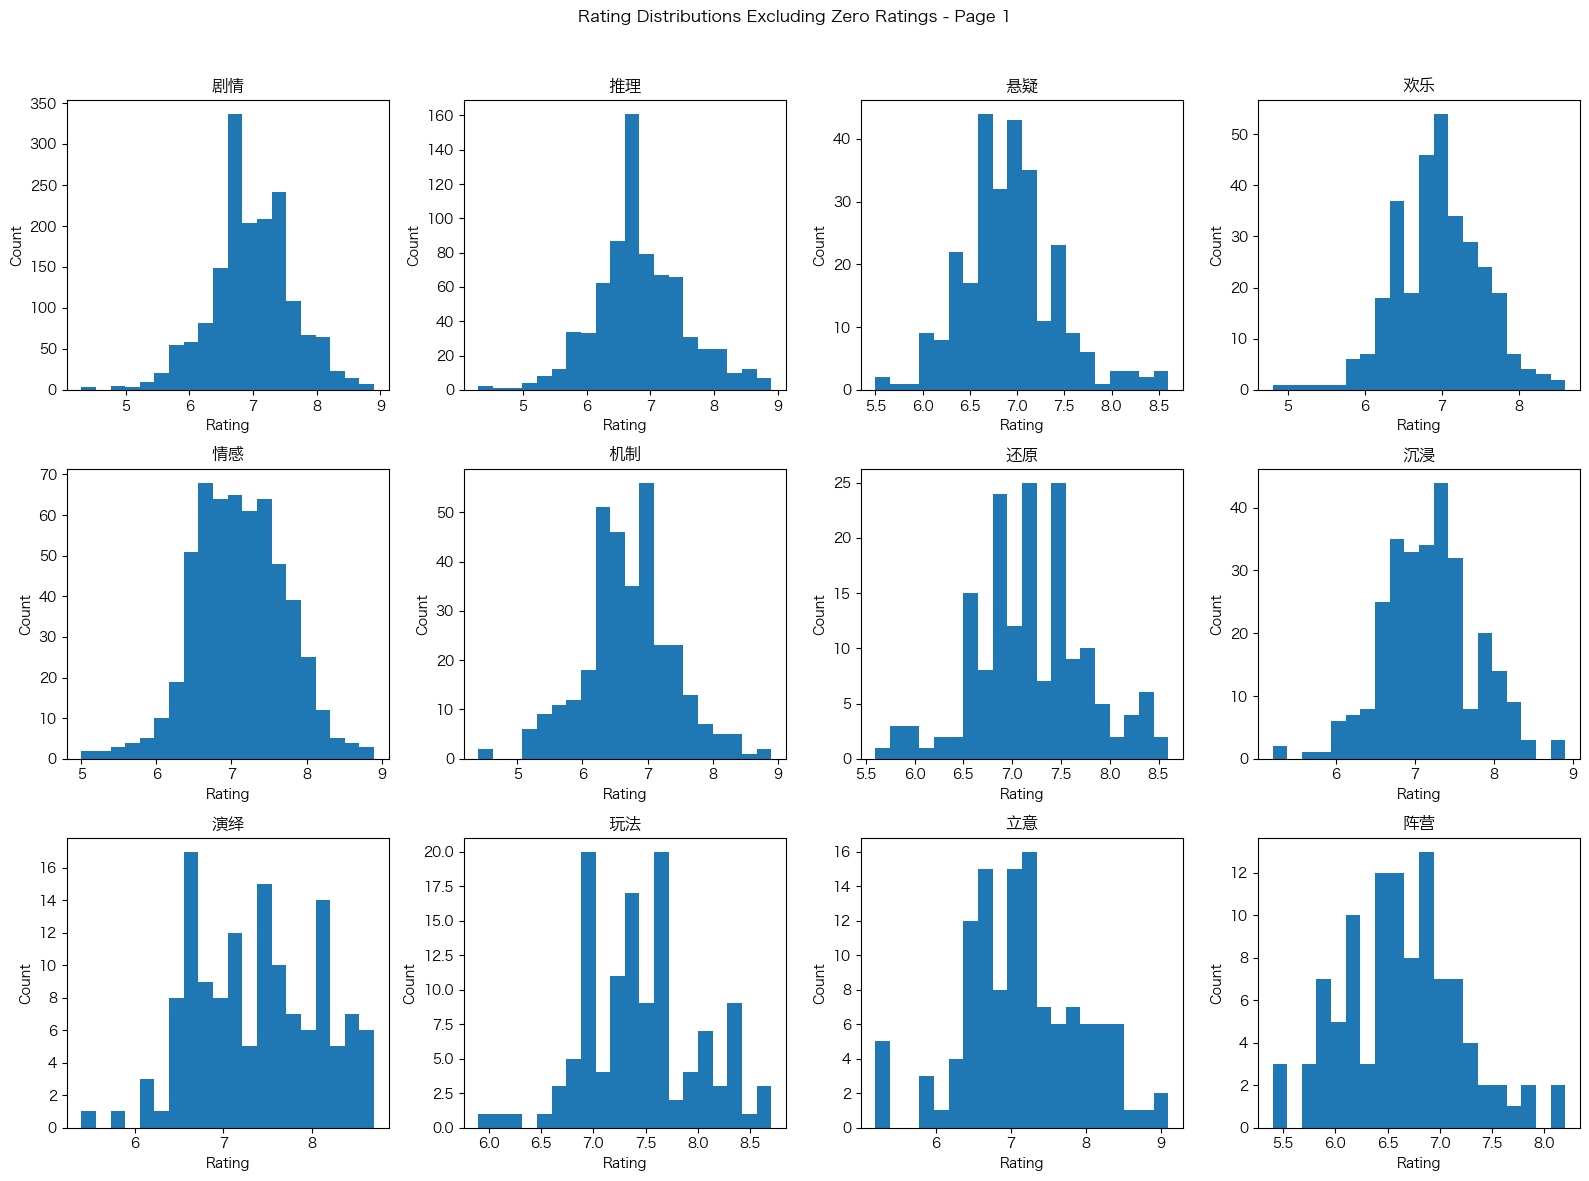

In [32]:
from matplotlib import font_manager
import math

preferred_fonts = [
    "PingFang SC",
    "Hiragino Sans GB",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

rating_columns_no_overall = [col for col in RATING_COLUMNS if col != "overall_rating" and col in ratings.columns]
nonzero_rating_data = {
    col: ratings_no_zero_one[col].dropna().loc[lambda s: s.gt(0)]
    for col in rating_columns_no_overall
}
positive_rating_columns = [col for col in rating_columns_no_overall if not nonzero_rating_data[col].empty]
zero_only_columns = [col for col in rating_columns_no_overall if nonzero_rating_data[col].empty]

print("Note: some rating subcategories only have 0 values after filtering, so they are excluded from the plots below.")
if zero_only_columns:
    print("Zero-only subcategories: " + ", ".join(zero_only_columns))


def plot_rating_hist_page(columns: list[str], title: str) -> None:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        values = nonzero_rating_data[col]
        ax.hist(values, bins=20)
        ax.set_title(col)
        ax.set_xlabel("Rating")
        ax.set_ylabel("Count")

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)


page_size = 12
for page_number, start in enumerate(range(0, len(positive_rating_columns), page_size), start=1):
    page_columns = positive_rating_columns[start : start + page_size]
    plot_rating_hist_page(page_columns, f"Rating Distributions Excluding Zero Ratings - Page {page_number}")